<a href="https://colab.research.google.com/github/MRazaRashid/SolvedMLNotebooks/blob/main/TASK_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` Train a KNN model on glass type dataset and find best n_neighnours.

Data Link: https://drive.google.com/file/d/17cbDNBmys04MJqQfrma3jd72VPMnxIq0/view?usp=share_link

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
df = pd.read_csv("glass.csv")
print(df.sample(10))
print(df.shape)


          RI     Na    Mg    Al     Si     K     Ca    Ba    Fe  Type
99   1.51811  12.96  2.96  1.43  72.92  0.60   8.79  0.14  0.00     2
70   1.51574  14.86  3.67  1.74  71.87  0.16   7.36  0.00  0.12     2
172  1.51321  13.00  0.00  3.02  70.70  6.21   6.93  0.00  0.00     5
210  1.51685  14.92  0.00  1.99  73.06  0.00   8.40  1.59  0.00     7
189  1.52365  15.79  1.83  1.31  70.43  0.31   8.61  1.68  0.00     7
176  1.51905  14.00  2.39  1.56  72.37  0.00   9.57  0.00  0.00     6
48   1.52223  13.21  3.77  0.79  71.99  0.13  10.02  0.00  0.00     1
50   1.52320  13.72  3.72  0.51  71.75  0.09  10.06  0.00  0.16     1
60   1.51905  13.60  3.62  1.11  72.64  0.14   8.76  0.00  0.00     1
166  1.52151  11.03  1.71  1.56  73.44  0.58  11.62  0.00  0.00     5
(214, 10)


In [23]:
print(df.columns.tolist())
print(df.isna().sum())

['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [24]:
print(df['Type'].value_counts())

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [25]:
X = df.drop(columns="Type")
y = df["Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)


In [26]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

best_k = list(k_range)[int(np.argmax(cv_scores))]
print("Best K:", best_k, " CV accuracy:", max(cv_scores))

Best K: 1  CV accuracy: 0.7


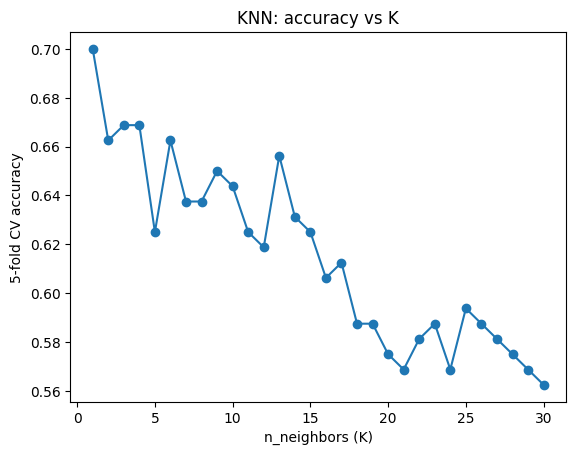

In [27]:
plt.plot(list(k_range), cv_scores, marker="o")
plt.xlabel("n_neighbors (K)")
plt.ylabel("5-fold CV accuracy")
plt.title("KNN: accuracy vs K")
plt.show()

In [28]:

final = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
final.fit(X_train, y_train)

test_pred = final.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred, zero_division=0))

Test accuracy: 0.7407407407407407
              precision    recall  f1-score   support

           1       0.80      0.67      0.73        18
           2       0.70      0.74      0.72        19
           3       0.40      0.50      0.44         4
           5       0.75      1.00      0.86         3
           6       0.50      0.50      0.50         2
           7       1.00      1.00      1.00         8

    accuracy                           0.74        54
   macro avg       0.69      0.73      0.71        54
weighted avg       0.75      0.74      0.74        54



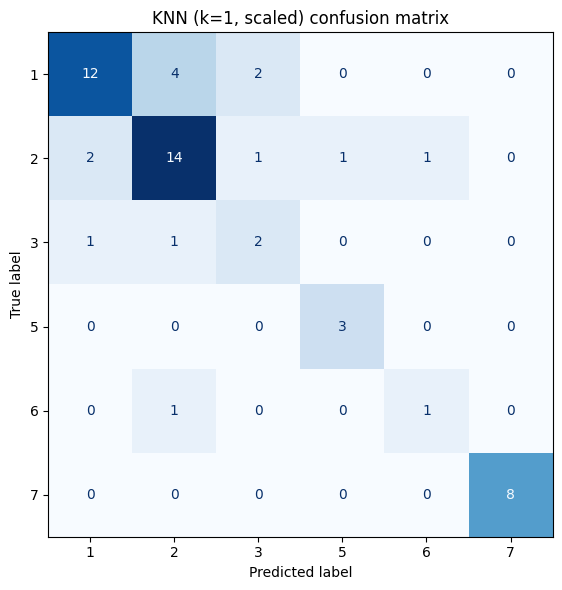

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred, labels=sorted(y_test.unique()))

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_test.unique()))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"KNN (k={best_k}, scaled) confusion matrix")
plt.tight_layout()
plt.show()